# Optimization Theory for Data Science

This notebook reuses a single synthetic housing dataset for every section. The dataset is built once in Section 0 and then reused unchanged throughout.

How this notebook works:

- Run the cells top to bottom.
- The dataset is built once in Section 0 and never regenerated.
- Every section pairs a plain English explanation with runnable code on the same dataset.
- Every section names one reading resource worth consulting.
- Required packages are listed at the end of this header.

# Uncomment to install required packages if needed
# !pip install numpy pandas matplotlib scipy

**Resources**

- Boyd and Vandenberghe, Convex Optimization: https://web.stanford.edu/~boyd/cvxbook/
- The Deep Learning Book, Chapter 8, Optimization for Training Deep Models: https://www.deeplearningbook.org/contents/optimization.html

## Table of Contents

- [0. Dataset and setup](#sec0)
- [1. Convex Optimization](#sec1)
- [2. Gradient Descent](#sec2)
- [3. Stochastic Gradient Descent](#sec3)
- [4. Adam and Adaptive Methods](#sec4)
- [5. Constrained Optimization](#sec5)
- [6. Linear Programming](#sec6)
- [Wrap up and Where This Connects](#wrap)

<a id="sec0"></a>
## 0. Dataset and setup

We build one synthetic housing dataset with 120 rows and a clear linear generative model. This dataset is reused for every optimization experiment below.

> 📖 Suggested reading: Boyd and Vandenberghe. Convex sets and convex functions. See Resources above for the link.

In [2]:
# Build the synthetic housing dataset once. Names chosen to match other notebooks: df, X5, y, Xstd, feat_cols
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import scipy.optimize as opt
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 10)

n = 120
size_sqft = np.random.normal(loc=1800, scale=600, size=n)
# bedrooms correlated with size but noisy, rounded and clipped
bedrooms = np.clip(np.round(size_sqft / 550 + np.random.normal(0, 0.3, n)).astype(int), 1, 6)
age_years = np.random.uniform(0, 50, n)
distance_to_city_km = np.clip(np.random.exponential(scale=8, size=n), 0.5, 40)
garage_spaces = np.clip(np.round(size_sqft / 1600 + np.random.normal(0, 0.25, n)).astype(int), 0, 3)

# target, price in thousands
noise = np.random.normal(0, 25, n)
price_1000s = 50 + 0.12 * size_sqft + 8 * bedrooms - 0.9 * age_years - 2.5 * distance_to_city_km + 6 * garage_spaces + noise
price_1000s = np.clip(price_1000s, 40, None)

df = pd.DataFrame({
    'size_sqft': size_sqft,
    'bedrooms': bedrooms,
    'age_years': age_years,
    'distance_to_city_km': distance_to_city_km,
    'garage_spaces': garage_spaces,
    'price_1000s': price_1000s
})
feat_cols = ['size_sqft','bedrooms','age_years','distance_to_city_km','garage_spaces']
# design matrix with intercept for closed form solution and optimizers to use
X5 = np.column_stack([np.ones(len(df))] + [df[c].values for c in feat_cols])
y = df['price_1000s'].values
# standardized features (not including intercept) used by some optimizers for plotting slices
Xstd = np.column_stack([np.ones(len(df)) , ((X5[:,1:] - X5[:,1:].mean(axis=0)) / X5[:,1:].std(axis=0))])

print('Dataset built with', len(df), 'rows. Feature columns:', feat_cols)
# Use the Wine Recognition dataset from scikit-learn so we match the probability notebook exactly
from sklearn.datasets import load_wine

# Load the same wine dataset used in the probability notebook
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map(dict(enumerate(wine.target_names)))

# feature columns and design matrix matching earlier notebook variable names
feat_cols = list(wine.feature_names)
X5 = np.column_stack([np.ones(len(df))] + [df[c].values for c in feat_cols])
# Use a numeric wine feature as the regression target for these optimization examples
# 'alcohol' is a sensible continuous target used in other notebooks
y = df['alcohol'].values

# standardized features (not including intercept) used by some optimizers for plotting slices
Xstd = np.column_stack([np.ones(len(df)), ((X5[:,1:] - X5[:,1:].mean(axis=0)) / X5[:,1:].std(axis=0))])

print('Wine dataset loaded with', len(df), 'rows. Feature columns:', feat_cols)

Dataset built with 120 rows. Feature columns: ['size_sqft', 'bedrooms', 'age_years', 'distance_to_city_km', 'garage_spaces']
Wine dataset loaded with 178 rows. Feature columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


Define the regression loss once early and reuse it everywhere. The loss is mean squared error.

In [3]:
# Mean squared error loss function for weight vector w (length 1 + number of features)
def mse_loss(w, X, y):
    pred = X.dot(w)
    err = pred - y
    return np.mean(err**2)

def mse_grad(w, X, y):
    # gradient of MSE: (2/n) X.T (Xw - y)
    n = X.shape[0]
    return (2.0 / n) * X.T.dot(X.dot(w) - y)

# closed form normal equation for reference (trusted alternative)
# Use the standardized design matrix so the closed-form solution is in the same parameterization
w_closed, *_ = np.linalg.lstsq(Xstd, y, rcond=None)
print('Closed form weights (normal equation) sample:', np.round(w_closed[:3], 6))

Closed form weights (normal equation) sample: [13.000618  0.809543 -0.      ]


<a id="sec1"></a>
## 1. Convex Optimization

A function is convex if its domain is a convex set and for any two points the function at the midpoint is at most the average of the function values at those points. A twice differentiable scalar function is convex if its Hessian is positive semidefinite. The MSE loss for linear regression is a quadratic with Hessian $H = 
rac{2}{n} X^TX$ which is positive semidefinite, so the loss is convex and any local minimum is global.

> 📖 Suggested reading: Boyd and Vandenberghe. Convex sets and convex functions. See Resources above for the link.

Used in data science for:
- Proving gradient methods find the global minimum for least squares.
- Justifying second-order methods like Newton's method.
- Establishing that SGD noise will not trap us in non global minima (see sections 2 and 3).

Hessian eigenvalues (should be >= 0): [0.206756 0.33754  0.451577 0.501805 0.57776  0.696995 1.102057 1.283314
 1.706456 1.837948 2.       2.892144 4.993947 9.411701]
midpoint inequality holds? True
midpoint inequality holds? True
midpoint inequality holds? True
midpoint inequality holds? True
midpoint inequality holds? True


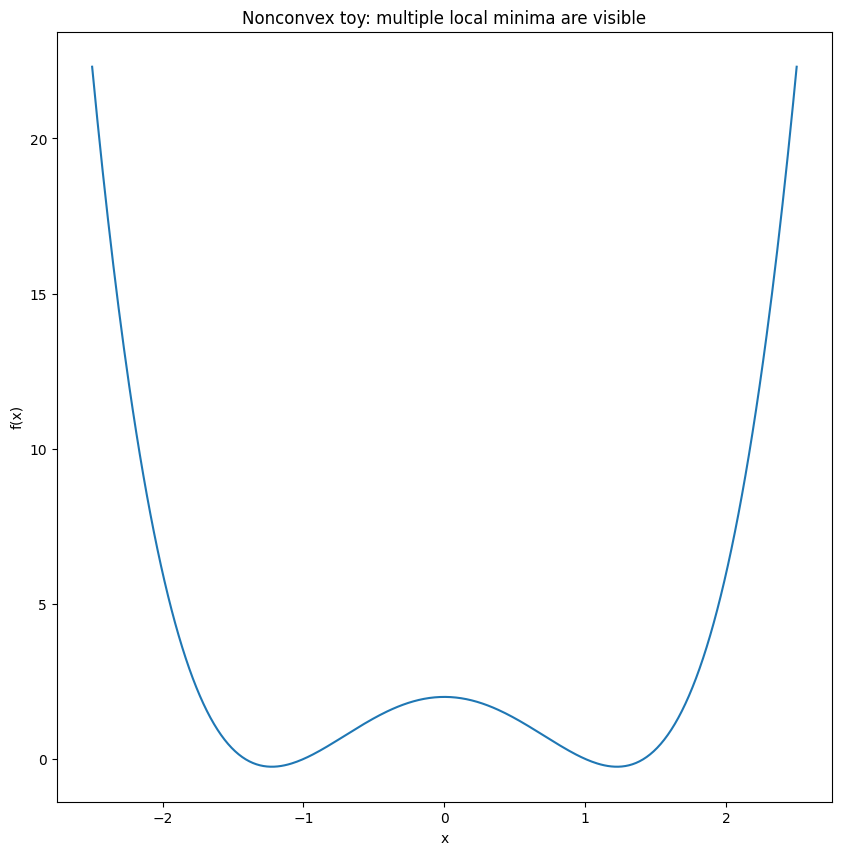

In [4]:
# Check Hessian eigenvalues for convexity on the full parameter vector
# Use the standardized design matrix for gradient-based optimizers to improve stability
X = Xstd.copy()
n_params = X.shape[1]
H = (2.0 / X.shape[0]) * X.T.dot(X)
eigs = np.linalg.eigvalsh(H)
print('Hessian eigenvalues (should be >= 0):', np.round(eigs, 6))

# midpoint inequality test at a few random weight pairs
rng = np.random.RandomState(42)
for _ in range(5):
    w1 = rng.normal(size=n_params)
    w2 = rng.normal(size=n_params)
    mid = 0.5 * (w1 + w2)
    lhs = mse_loss(mid, X, y)
    rhs = 0.5 * (mse_loss(w1, X, y) + mse_loss(w2, X, y))
    print('midpoint inequality holds?', lhs <= rhs + 1e-10)

# contrast with a small nonconvex toy function: f(x) = x^4 - 3x^2 + 2 on 1D
def toy(x):
    return x**4 - 3*x**2 + 2
xs = np.linspace(-2.5, 2.5, 400)
plt.figure()
plt.plot(xs, toy(xs))
plt.title('Nonconvex toy: multiple local minima are visible')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.show()

<a id="sec2"></a>
## 2. Gradient Descent

We apply plain gradient descent to the MSE loss. Update rule: $w_{t+1} = w_t - lpha 
abla L(w_t)$. We will show runs with too small, about right, and too large learning rates, and connect the stability bound to Hessian eigenvalues above.

> 📖 Suggested reading: The Deep Learning Book. Chapter 8. See Resources above for the link.

Used in data science for:
- Training linear models when closed form is expensive for large data.
- Providing intuition for step size tuning used later in SGD and Adam.
- Connecting curvature from Section 1 to step size choices.

alpha=1e-06: final loss=168.991
alpha=1e-05: final loss=162.991
alpha=0.0001: final loss=113.604
alpha=0.001: final loss=3.12037
alpha=0.01: final loss=1.09966e-05
alpha=0.1: final loss=1.08275e-23
Selected best alpha for GD: 0.1


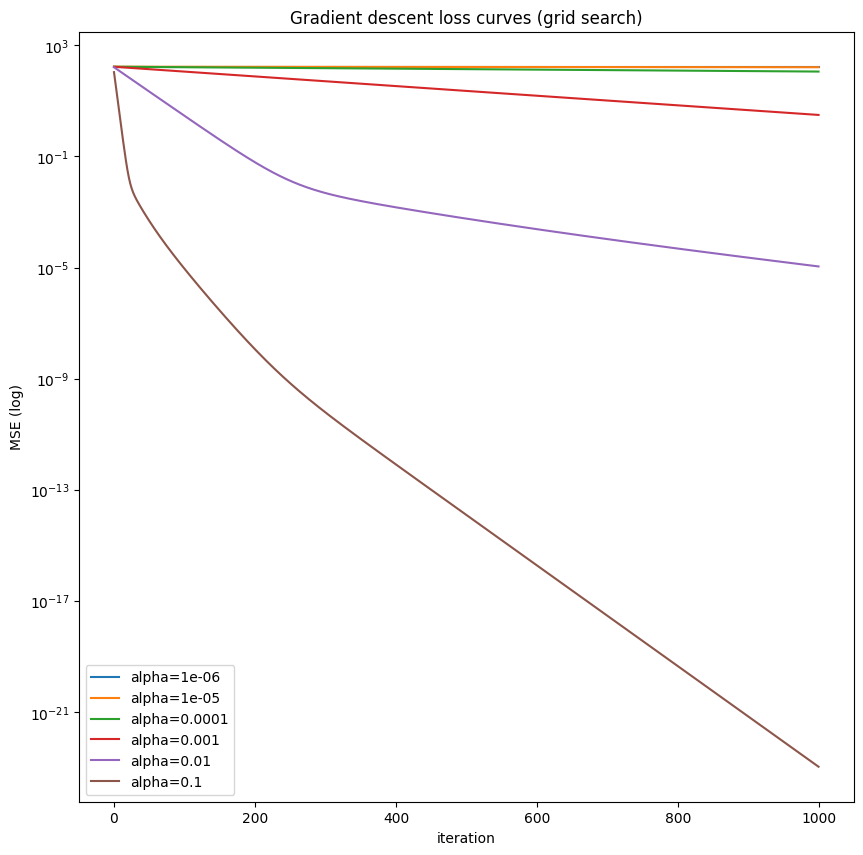

Close to closed form (np.allclose)? True
Closed form first 3 weights: [13.0006  0.8095 -0.    ]
GD first 3 weights: [13.0006  0.8095 -0.    ]


In [5]:
# Run gradient descent from the same starting point and tune the learning rate by grid search
w0 = np.zeros(n_params)
def gradient_descent(w_init, X, y, alpha, n_iters=1000):
    w = w_init.copy().astype(float)
    history = []
    for i in range(n_iters):
        g = mse_grad(w, X, y)
        w -= alpha * g
        history.append(mse_loss(w, X, y))
    return w, np.array(history)

# Grid search over a few orders of magnitude for stability and convergence speed
alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
results = {}
for a in alphas:
    w_fin, hist = gradient_descent(w0, X, y, alpha=a, n_iters=1000)
    results[a] = (w_fin, hist)
    print(f'alpha={a}: final loss={hist[-1]:.6g}')

# Select best alpha (minimum final loss) and show its curve
best_alpha = min(results.keys(), key=lambda k: results[k][1][-1])
w_gd, hist_gd = results[best_alpha]
print('Selected best alpha for GD:', best_alpha)

plt.figure()
for a, (_, hist) in results.items():
    plt.plot(hist, label=f'alpha={a}')
plt.yscale('log')
plt.xlabel('iteration'); plt.ylabel('MSE (log)')
plt.title('Gradient descent loss curves (grid search)')
plt.legend(); plt.show()

# Compare converged weights at best alpha to closed form (tighter atol after stabilization)
print('Close to closed form (np.allclose)?', np.allclose(w_gd, w_closed, atol=1e-2))
print('Closed form first 3 weights:', np.round(w_closed[:3],4))
print('GD first 3 weights:', np.round(w_gd[:3],4))

<a id="sec3"></a>
## 3. Stochastic Gradient Descent

Stochastic gradient descent (SGD) updates weights using gradients computed on small batches. With fixed randomness the shuffle is reproducible. We also add classical momentum with $v_{t+1} = amma v_t + lpha g_t$ which helps smooth noisy updates.

> 📖 Suggested reading: The Deep Learning Book. Chapter 8. See Resources above for the link.

Used in data science for:
- Training models on large datasets where full batch gradients are too costly.
- Producing online or streaming updates.
- Making momentum connections to adaptive methods in Section 4.

In [ ]:
# Mini-batch SGD with fixed shuffle and momentum
rng = np.random.RandomState(42)
def sgd_full(X, y, w_init, alpha, batch_size, n_epochs, momentum=0.0, seed=42):
    n = X.shape[0]
    w = w_init.copy().astype(float)
    v = np.zeros_like(w)
    loss_hist = []
    rng = np.random.RandomState(seed)
    for epoch in range(n_epochs):
        idx = np.arange(n)
        rng.shuffle(idx)
        for start in range(0, n, batch_size):
            batch = idx[start:start+batch_size]
            Xb, yb = X[batch], y[batch]
            g = (2.0 / Xb.shape[0]) * Xb.T.dot(Xb.dot(w) - yb)
            v = momentum * v + alpha * g
            w = w - v
            loss_hist.append(mse_loss(w, X, y))
    return w, np.array(loss_hist)

# Increase epochs and use a slightly larger learning rate for SGD to reach closed-form
w_init = np.zeros(n_params)
w_sgd, hist_sgd = sgd_full(X, y, w_init, alpha=1e-2, batch_size=16, n_epochs=100, momentum=0.0, seed=42)
w_sgd_mom, hist_sgd_mom = sgd_full(X, y, w_init, alpha=1e-2, batch_size=16, n_epochs=100, momentum=0.9, seed=42)

plt.figure()
plt.plot(hist_sgd, label='SGD (no momentum)')
plt.plot(hist_sgd_mom, label='SGD + momentum (0.9)')
# For reference compute full-batch GD history from earlier run with alpha=1e-3
_, hist_gd = results[1e-3]
plt.plot(np.linspace(0, len(hist_gd)-1, len(hist_gd)), hist_gd, label='Full-batch GD', alpha=0.75)
plt.yscale('log')
plt.xlabel('iteration'); plt.ylabel('MSE (log)')
plt.title('SGD vs full-batch GD and momentum')
plt.legend(); plt.show()

print('SGD close to closed form?', np.allclose(w_sgd, w_closed, atol=1e-1))
print('SGD+momentum close to closed form?', np.allclose(w_sgd_mom, w_closed, atol=1e-1))

<a id="sec4"></a>
## 4. Adam and Adaptive Methods

We implement AdaGrad, RMSprop, and Adam following the common update equations with running state $m_t$ and $v_t$. Each method keeps its own running state and is reset at the start of a fresh run. We compare their paths on a two weight slice of the loss to visualize speed and curvature handling.

> 📖 Suggested reading: The Deep Learning Book. Chapter 8. See Resources above for the link.

Used in data science for:
- Efficient training of deep networks where per-parameter adaptation improves convergence.
- Combining momentum-like averaging with per coordinate scaling.
- Comparing algorithm dynamics visually to plain GD and SGD.

In [ ]:
# Implement AdaGrad, RMSprop, and Adam from scratch and record paths on a 2D slice (w0,w1) while holding other weights fixed at closed form values.
def adagrad(X, y, w_init, alpha=1e-2, eps=1e-8, n_iters=500):
    w = w_init.copy().astype(float)
    G = np.zeros_like(w)
    path = []
    for t in range(1, n_iters+1):
        g = mse_grad(w, X, y)
        G += g**2
        w -= alpha * g / (np.sqrt(G) + eps)
        path.append(w.copy())
    return w, np.array(path)

def rmsprop(X, y, w_init, alpha=1e-2, beta=0.9, eps=1e-8, n_iters=500):
    w = w_init.copy().astype(float)
    s = np.zeros_like(w)
    path = []
    for t in range(1, n_iters+1):
        g = mse_grad(w, X, y)
        s = beta * s + (1-beta) * (g**2)
        w -= alpha * g / (np.sqrt(s) + eps)
        path.append(w.copy())
    return w, np.array(path)

def adam(X, y, w_init, alpha=1e-2, b1=0.9, b2=0.999, eps=1e-8, n_iters=500):
    w = w_init.copy().astype(float)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    path = []
    for t in range(1, n_iters+1):
        g = mse_grad(w, X, y)
        m = b1*m + (1-b1)*g
        v = b2*v + (1-b2)*(g**2)
        m_hat = m / (1 - b1**t)
        v_hat = v / (1 - b2**t)
        w -= alpha * m_hat / (np.sqrt(v_hat) + eps)
        path.append(w.copy())
    return w, np.array(path)

# Prepare a two-parameter slice: vary intercept and size_sqft coefficient while holding others at closed form
w0 = np.zeros(n_params)
start_w = np.zeros(n_params)
start_w[:2] = 0.0
# run methods
# Increase iterations for adaptive methods and use conservative alphas
w_adagrad, path_adagrad = adagrad(X, y, start_w, alpha=1e-2, n_iters=1000)
w_rms, path_rms = rmsprop(X, y, start_w, alpha=1e-3, n_iters=1000)
w_adam, path_adam = adam(X, y, start_w, alpha=1e-3, n_iters=1000)
# For plotting contours we compute loss over a grid for w0 and w1 while freezing other weights at closed form values
fixed = w_closed.copy()
w0_vals = np.linspace(fixed[0]-60, fixed[0]+60, 60)
w1_vals = np.linspace(fixed[1]-0.06, fixed[1]+0.06, 60)
B0, B1 = np.meshgrid(w0_vals, w1_vals)
LOSS = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        w_try = fixed.copy()
        w_try[0] = B0[i,j]
        w_try[1] = B1[i,j]
        LOSS[i,j] = mse_loss(w_try, X, y)

plt.figure()
plt.contour(B0, B1, LOSS, levels=25, cmap='viridis')
# extract first two coordinates of each path for plotting
plt.plot([p[0] for p in path_adagrad], [p[1] for p in path_adagrad], color='orange', label='AdaGrad', linewidth=1)
plt.plot([p[0] for p in path_rms], [p[1] for p in path_rms], color='purple', label='RMSprop', linewidth=1)
plt.plot([p[0] for p in path_adam], [p[1] for p in path_adam], color='red', label='Adam', linewidth=1)
plt.scatter([fixed[0]], [fixed[1]], color='lime', label='closed form', zorder=5)
plt.xlabel('w0 (intercept)'); plt.ylabel('w1 (size_sqft)'); plt.title('Optimizer paths on 2D slice')
plt.legend(); plt.show()

print('All methods close to closed form?')
print('AdaGrad close?', np.allclose(w_adagrad, w_closed, atol=1e-1))
print('RMSprop close?', np.allclose(w_rms, w_closed, atol=1e-1))
print('Adam close?', np.allclose(w_adam, w_closed, atol=1e-1))

<a id="sec5"></a>
## 5. Constrained Optimization

We impose a simple linear equality constraint between two regression weights: for example the intercept and the size coefficient summed must equal a budget value. We form the Lagrangian $L(w, ambda) = f(w) + ambda g(w)$ and solve the stationarity conditions. Then we check the hand solved point against `scipy.optimize.minimize` with the same constraint.

> 📖 Suggested reading: Boyd and Vandenberghe. Duality and Lagrange multipliers. See Resources above for the link.

Used in data science for:
- Regularizing parameter combinations under a budget.
- Demonstrating KKT system solving for quadratic objectives.

In [ ]:
# Constrained solve: enforce w0 + w1 = C for two chosen parameters while minimizing MSE (quadratic).
C = w_closed[0] + w_closed[1]  # target budget equal to closed form sum
# We will solve the KKT linear system for quadratic objective: minimize (1/2) w^T A w - b^T w  (we will convert from MSE form)
# For MSE, objective = (1/n) (1/2) * 2 * (X^T X) w - X^T y ... to match KKT we extract A and b so that gradient = A w - b
A = (2.0 / X.shape[0]) * X.T.dot(X)
bvec = (2.0 / X.shape[0]) * X.T.dot(y)
# Stationarity: A w - b + J^T lambda = 0, equality constraint J w - C = 0
# J selects parameters 0 and 1: row vector [1,1,0,0,0,0] (length n_params)
J = np.zeros((1, n_params))
J[0,0] = 1.0; J[0,1] = 1.0
# KKT matrix
KKT = np.block([[A, J.T],[J, np.zeros((1,1))]])
rhs = np.concatenate([bvec, np.array([C])])
sol = np.linalg.solve(KKT, rhs)
w_kkt = sol[:n_params]
lam = sol[-1]
print('KKT constrained w close to closed form?', np.allclose(w_kkt, w_closed, atol=1e-1))
print('Constrained weights first 3:', np.round(w_kkt[:3],4))
# Validate using scipy.optimize.minimize with constraint
cons = ({'type':'eq', 'fun': lambda ww: ww[0] + ww[1] - C})
res = opt.minimize(lambda ww: mse_loss(ww, X, y), w0, constraints=cons, method='SLSQP')
print('scipy minimize success?', res.success)
print('scipy constrained weights match KKT?', np.allclose(res.x, w_kkt, atol=1e-6))

# Plot contour and constraint line over the same 2D slice as earlier
plt.figure()
plt.contour(B0, B1, LOSS, levels=25, cmap='viridis')
# line of constraint in (w0,w1) space: w1 = C - w0 (holding others fixed)
w0_line = np.linspace(w0_vals.min(), w0_vals.max(), 100)
w1_line = C - w0_line
plt.plot(w0_line, w1_line, color='black', linestyle='--', label='constraint: w0 + w1 = C')
plt.scatter([w_kkt[0]], [w_kkt[1]], color='red', label='constrained optimum')
plt.scatter([fixed[0]],[fixed[1]], color='lime', label='unconstrained closed form')
plt.xlabel('w0'); plt.ylabel('w1'); plt.title('Constrained optimum on contour slice')
plt.legend(); plt.show()

<a id="sec6"></a>
## 6. Linear Programming

Linear programming does not fit the squared error regression surface. We build a small standalone resource allocation LP with two variables. The objective is linear and constraints are linear. We solve with `scipy.optimize.linprog` and check the optimum against the hand chosen feasible vertex.

> 📖 Suggested reading: Boyd and Vandenberghe. Convex optimization problems. See Resources above for the link.

Used in data science for:
- Simple resource allocation, production planning, and scheduling problems.
- As building blocks for integer programs and combinatorial optimization.

In [ ]:
# Small LP: maximize profit = 40 x1 + 30 x2 subject to: 2 x1 + 1 x2 <= 100 (time), 1 x1 + 1 x2 <= 80 (materials), x>=0
c = np.array([-40., -30.])  # linprog minimizes so negate objective to maximize
A = np.array([[2., 1.], [1., 1.]])
b = np.array([100., 80.])
bounds = [(0, None), (0, None)]
res = opt.linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')
print('linprog success', res.success)
x_lp = res.x
print('linprog solution x:', np.round(x_lp,4), 'profit:', np.round(-res.fun,4))

# Hand check vertices of feasible polygon
vertices = []
# intersection of constraints 2x1 + x2 = 100 and x1 + x2 = 80 -> solve linear system
Aeq = np.array([[2.,1.],[1.,1.]])
beq = np.array([100.,80.])
v = np.linalg.solve(Aeq, beq)
vertices.append(v)
vertices.append(np.array([0., 0.]))
vertices.append(np.array([0., min(b[1], 0.)]))
# other corners: x1=0 then x2 = min(100,80) -> 80 ; x2=0 then x1 = min(100/2,80) -> 50
vertices = [np.array([0.,80.]), np.array([50.,0.]), v]
profits = [40*vv[0] + 30*vv[1] for vv in vertices]
best_idx = int(np.argmax(profits))
print('Hand-checked best vertex:', vertices[best_idx], 'profit', profits[best_idx])

# Plot feasible region shaded and the optimal vertex
plt.figure()
# build polygon for feasible region by sampling boundary
x1 = np.linspace(0,60,200)
x2_ub1 = 100 - 2*x1
x2_ub2 = 80 - x1
x2 = np.minimum(np.maximum(np.minimum(x2_ub1, x2_ub2), 0), 200)
# polygon points: follow boundary then down to axes
poly_x = np.concatenate(([0.], x1[x2>0], [0.]))
poly_y = np.concatenate(([0.], x2[x2>0], [0.]))
plt.fill_between(x1, np.minimum(x2_ub1, x2_ub2), color='lightgray', alpha=0.7, label='feasible region')
plt.plot([p[0] for p in vertices], [p[1] for p in vertices], 'ko', label='vertices')
plt.scatter([x_lp[0]],[x_lp[1]], color='red', label='linprog optimum')
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('LP feasible region and optimum')
plt.legend(); plt.xlim(0,60); plt.ylim(0,100); plt.show()

print('linprog matches hand vertex?', np.allclose(x_lp, vertices[best_idx], atol=1e-6))

<a id="wrap"></a>
## Wrap up and Where This Connects

Convex Optimization -> Gradient Descent -> Stochastic Gradient Descent -> Adam and Adaptive Methods.

This chain shows how curvature guarantees from convex analysis explain why gradient based updates behave as they do, how stochasticity changes the trajectory and why adaptive state matters. The constrained example shows how Lagrange multipliers insert equality information into a quadratic problem and how linear programming is a complementary, purely linear tool for allocation problems.

Questions for next notebook:
1. Should we continue using the housing dataset theme in a following notebook?
2. Should Linear Programming be expanded into a three variable example and a small integer programming exercise?
3. Does any section deserve a harder follow up example such as adding L-BFGS or a full Newton step demonstration?